# Практика: Влияние инициализации и скорости обучения на MNIST

В этом практическом занятии мы исследуем, как начальная инициализация весов и скорость обучения влияют на обучение нейронной сети на реальном наборе данных MNIST (рукописные цифры). Мы будем использовать простую полносвязную сеть (MLP) с двумя скрытыми слоями.

**Цели:**
- Научиться загружать и подготавливать данные MNIST.
- Сравнить различные инициализации (по умолчанию, Xavier, He, случайная большая).
- Исследовать влияние скорости обучения на сходимость.
- Визуализировать процесс обучения и полученные признаки.

**Задание: повторить все действия и сделать выводы для набора данных Fashion-MNIST.**

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# Фиксируем seed для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

## 1. Загрузка и предобработка данных MNIST

Загрузим обучающую и тестовую выборки, нормализуем изображения и создадим DataLoader'ы. Для ускорения эксперимента возьмём только первые 10000 обучающих примеров и 2000 тестовых.

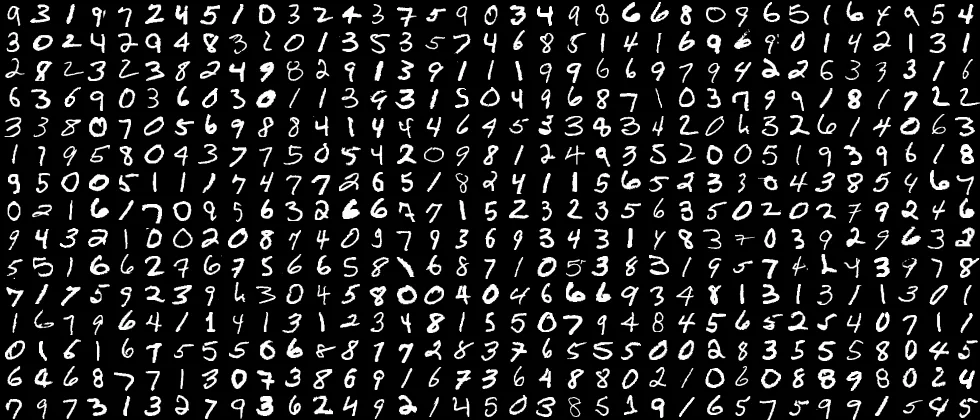

In [12]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # среднее и std для MNIST
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Ограничим выборку для быстроты
train_dataset = torch.utils.data.Subset(train_dataset, range(10000))
test_dataset = torch.utils.data.Subset(test_dataset, range(2000))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

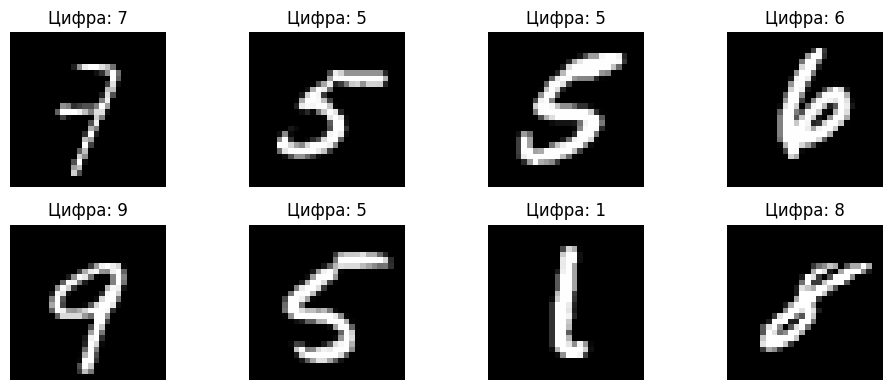

In [13]:
# Посмотрим на несколько изображений
images, labels = next(iter(train_loader))
plt.figure(figsize=(10,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title(f'Цифра: {labels[i].item()}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## 2. Определение модели

Создадим MLP с двумя скрытыми слоями (256 и 128 нейронов) и выходным слоем на 10 классов (softmax не включаем, так как будем использовать CrossEntropyLoss).

In [14]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden1=256, hidden2=128, output_size=10):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden2, output_size)
        # без softmax, его добавит loss

    def forward(self, x):
        x = x.view(x.size(0), -1)  # вытягиваем изображения в вектор
        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))
        x = self.fc3(x)
        return x

def init_weights(m, mode='default'):
    if isinstance(m, nn.Linear):
        if mode == 'normal':
            nn.init.normal_(m.weight, mean=0, std=1.0)
            nn.init.zeros_(m.bias)
        elif mode == 'xavier':
            nn.init.xavier_normal_(m.weight)
            nn.init.zeros_(m.bias)
        elif mode == 'he':
            nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
            nn.init.zeros_(m.bias)
        elif mode == 'default':
            pass  # оставляем умолчательную

## 3. Функция для обучения и оценки

Определим функцию, которая принимает модель, загрузчики, число эпох, скорость обучения и тип инициализации, обучает и возвращает историю потерь и точности.

In [15]:
def train_and_evaluate(model, train_loader, test_loader, epochs=5, lr=0.01, init_mode='default'):
    model.apply(lambda m: init_weights(m, init_mode))
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # Пустые массивы для накопления истории обучения
    train_losses = []
    test_losses = []
    train_accs = []
    test_accs = []

    for epoch in range(epochs):
        # Это только перевод в режим обучения
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        # Перебор всех жанных из обучающей выборки
        for images, labels in train_loader:
            optimizer.zero_grad()
            # Прямой проход
            outputs = model(images)
            # Текущее значение функции потерь
            loss = criterion(outputs, labels)
            # Обратное распространение ошибки.
            loss.backward()

            # обновление весов модели на основе градиентов.
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        # Обновление метрик после прохода всех данных
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct_train / total_train
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        # Оценка на тесте
        model.eval()
        test_loss = 0.0
        correct_test = 0
        total_test = 0
        with torch.no_grad():
            for images, labels in test_loader:
                outputs = model(images)
                loss = criterion(outputs, labels)
                test_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total_test += labels.size(0)
                correct_test += (predicted == labels).sum().item()

        epoch_test_loss = test_loss / len(test_loader.dataset)
        epoch_test_acc = correct_test / total_test
        test_losses.append(epoch_test_loss)
        test_accs.append(epoch_test_acc)

        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.4f}')

    return train_losses, test_losses, train_accs, test_accs

## 4. Эксперимент 1: Сравнение инициализаций

Зафиксируем скорость обучения `lr = 0.01` и сравним четыре инициализации: по умолчанию, Xavier, He, случайная нормальная с большой дисперсией (std=1). Обучим каждую модель в течение 5 эпох.

In [16]:
init_modes = ['default', 'xavier', 'he', 'normal']
histories = {}

for mode in init_modes:
    print(f"\n=== Инициализация: {mode} ===")
    model = MLP()
    train_loss, test_loss, train_acc, test_acc = train_and_evaluate(
        model, train_loader, test_loader, epochs=5, lr=0.01, init_mode=mode
    )
    histories[mode] = {
        'train_loss': train_loss,
        'test_loss': test_loss,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'model': model
    }


=== Инициализация: default ===
Epoch 1/5 | Train Loss: 1.9573 | Test Loss: 1.5251 | Test Acc: 0.6850
Epoch 2/5 | Train Loss: 0.9627 | Test Loss: 0.8017 | Test Acc: 0.7930
Epoch 3/5 | Train Loss: 0.5600 | Test Loss: 0.5963 | Test Acc: 0.8350
Epoch 4/5 | Train Loss: 0.4358 | Test Loss: 0.5180 | Test Acc: 0.8490
Epoch 5/5 | Train Loss: 0.3774 | Test Loss: 0.4679 | Test Acc: 0.8630

=== Инициализация: xavier ===
Epoch 1/5 | Train Loss: 0.9504 | Test Loss: 0.6451 | Test Acc: 0.8095
Epoch 2/5 | Train Loss: 0.4182 | Test Loss: 0.4899 | Test Acc: 0.8550
Epoch 3/5 | Train Loss: 0.3267 | Test Loss: 0.4220 | Test Acc: 0.8755
Epoch 4/5 | Train Loss: 0.2783 | Test Loss: 0.3885 | Test Acc: 0.8895
Epoch 5/5 | Train Loss: 0.2462 | Test Loss: 0.3631 | Test Acc: 0.8935

=== Инициализация: he ===
Epoch 1/5 | Train Loss: 0.8637 | Test Loss: 0.5982 | Test Acc: 0.8280
Epoch 2/5 | Train Loss: 0.3863 | Test Loss: 0.4546 | Test Acc: 0.8650
Epoch 3/5 | Train Loss: 0.3005 | Test Loss: 0.3974 | Test Acc: 0.8850


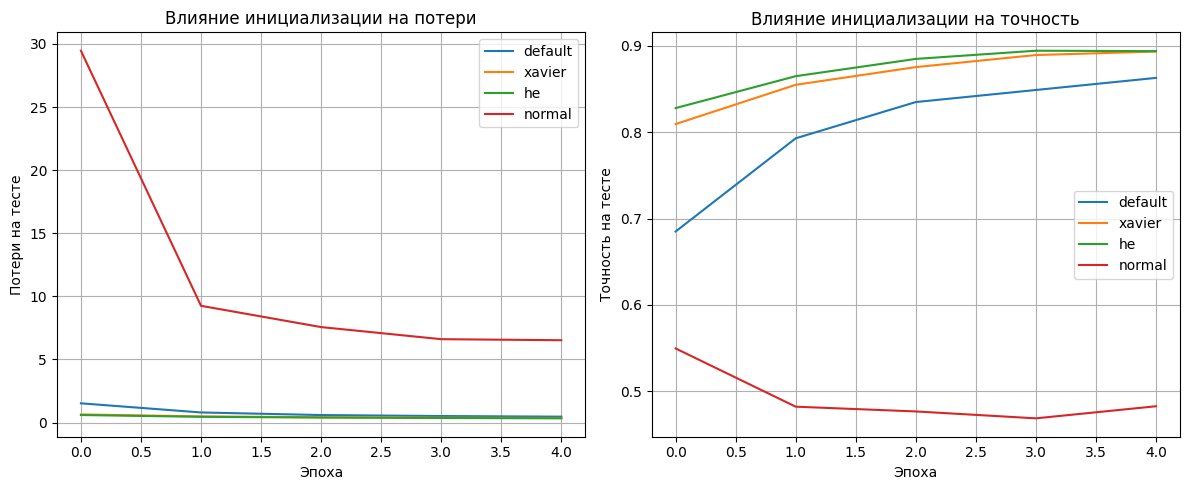

In [17]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for mode in init_modes:
    plt.plot(histories[mode]['test_loss'], label=mode)
plt.xlabel('Эпоха')
plt.ylabel('Потери на тесте')
plt.title('Влияние инициализации на потери')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
for mode in init_modes:
    plt.plot(histories[mode]['test_acc'], label=mode)
plt.xlabel('Эпоха')
plt.ylabel('Точность на тесте')
plt.title('Влияние инициализации на точность')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Вопросы для анализа:**
- Какая инициализация обеспечила наилучшую точность?

Xavier и He обе достигли 90% точности и показали быструю сходимость с низкими потерями.

- Почему инициализация 'normal' (std=1) работает хуже?


При std=1 начальные веса слишком большие и активации на выходе слоёв сразу попадают в зону насыщения или дают слишком большие значения.

- Соответствуют ли результаты теоретическим ожиданиям (He лучше для ReLU)?

Теоретически He инициализация оптимальна именно для ReLU, так как учитывает, что ReLU обнуляет половину нейронов, и компенсирует это масштабом. Xavier рассчитана на симметричные активации. Однако на обе показали почти одинаковый результат.

## 5. Эксперимент 2: Влияние скорости обучения

Теперь зафиксируем инициализацию He (как лучшую для ReLU) и сравним три значения скорости обучения: 0.001, 0.01, 0.1.

In [18]:
lrs = [0.001, 0.01, 0.1]
lr_histories = {}

for lr in lrs:
    print(f"\n=== Learning rate: {lr} ===")
    model = MLP()
    train_loss, test_loss, train_acc, test_acc = train_and_evaluate(
        model, train_loader, test_loader, epochs=5, lr=lr, init_mode='he'
    )
    lr_histories[lr] = {
        'train_loss': train_loss,
        'test_loss': test_loss,
        'train_acc': train_acc,
        'test_acc': test_acc,
        'model': model
    }


=== Learning rate: 0.001 ===
Epoch 1/5 | Train Loss: 2.1187 | Test Loss: 1.7180 | Test Acc: 0.4480
Epoch 2/5 | Train Loss: 1.3072 | Test Loss: 1.2668 | Test Acc: 0.6265
Epoch 3/5 | Train Loss: 0.9654 | Test Loss: 1.0302 | Test Acc: 0.7055
Epoch 4/5 | Train Loss: 0.7852 | Test Loss: 0.8881 | Test Acc: 0.7425
Epoch 5/5 | Train Loss: 0.6765 | Test Loss: 0.7957 | Test Acc: 0.7690

=== Learning rate: 0.01 ===
Epoch 1/5 | Train Loss: 0.8986 | Test Loss: 0.6154 | Test Acc: 0.8110
Epoch 2/5 | Train Loss: 0.4015 | Test Loss: 0.4750 | Test Acc: 0.8660
Epoch 3/5 | Train Loss: 0.3140 | Test Loss: 0.4158 | Test Acc: 0.8760
Epoch 4/5 | Train Loss: 0.2674 | Test Loss: 0.3767 | Test Acc: 0.8875
Epoch 5/5 | Train Loss: 0.2342 | Test Loss: 0.3553 | Test Acc: 0.8975

=== Learning rate: 0.1 ===
Epoch 1/5 | Train Loss: 0.4489 | Test Loss: 0.4290 | Test Acc: 0.8535
Epoch 2/5 | Train Loss: 0.1702 | Test Loss: 0.5143 | Test Acc: 0.8345
Epoch 3/5 | Train Loss: 0.1082 | Test Loss: 0.2904 | Test Acc: 0.9050
Epo

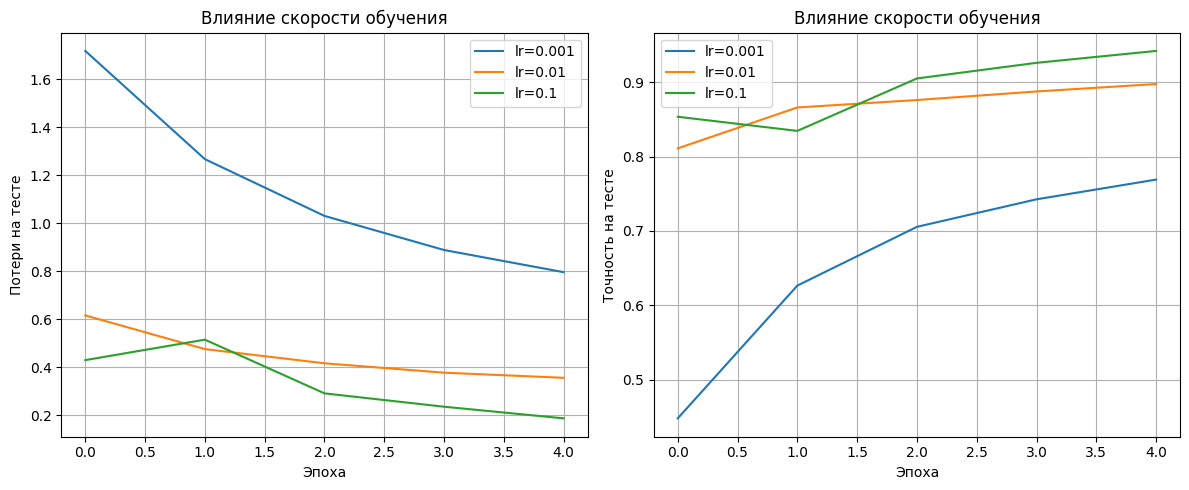

In [19]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for lr in lrs:
    plt.plot(lr_histories[lr]['test_loss'], label=f'lr={lr}')
plt.xlabel('Эпоха')
plt.ylabel('Потери на тесте')
plt.title('Влияние скорости обучения')
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
for lr in lrs:
    plt.plot(lr_histories[lr]['test_acc'], label=f'lr={lr}')
plt.xlabel('Эпоха')
plt.ylabel('Точность на тесте')
plt.title('Влияние скорости обучения')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Вопросы:**
- Какое значение learning rate дало наилучший результат?

lr=0.1 — наименьшие потери (~0.2) и наивысшая точность (92%).

- Наблюдается ли переобучение или недообучение при каком-либо lr?

Недообучение видно при lr=0.001 модель не успевает обучиться за 4 эпохи, потери всё ещё высокие (~1.0) и продолжают снижаться.

- Что произойдёт, если взять lr = 1.0? (можно проверить самостоятельно)

Потери, скорее всего, будут хаотично скакать или расти - слишком большой шаг приведёт к тому, что оптимизатор будет перепрыгивать минимум функции потерь.

## 6. Визуализация весов первого слоя

Для лучшей модели (например, He + lr=0.01) визуализируем веса первого слоя как изображения 28x28, чтобы увидеть, какие паттерны выучили нейроны.

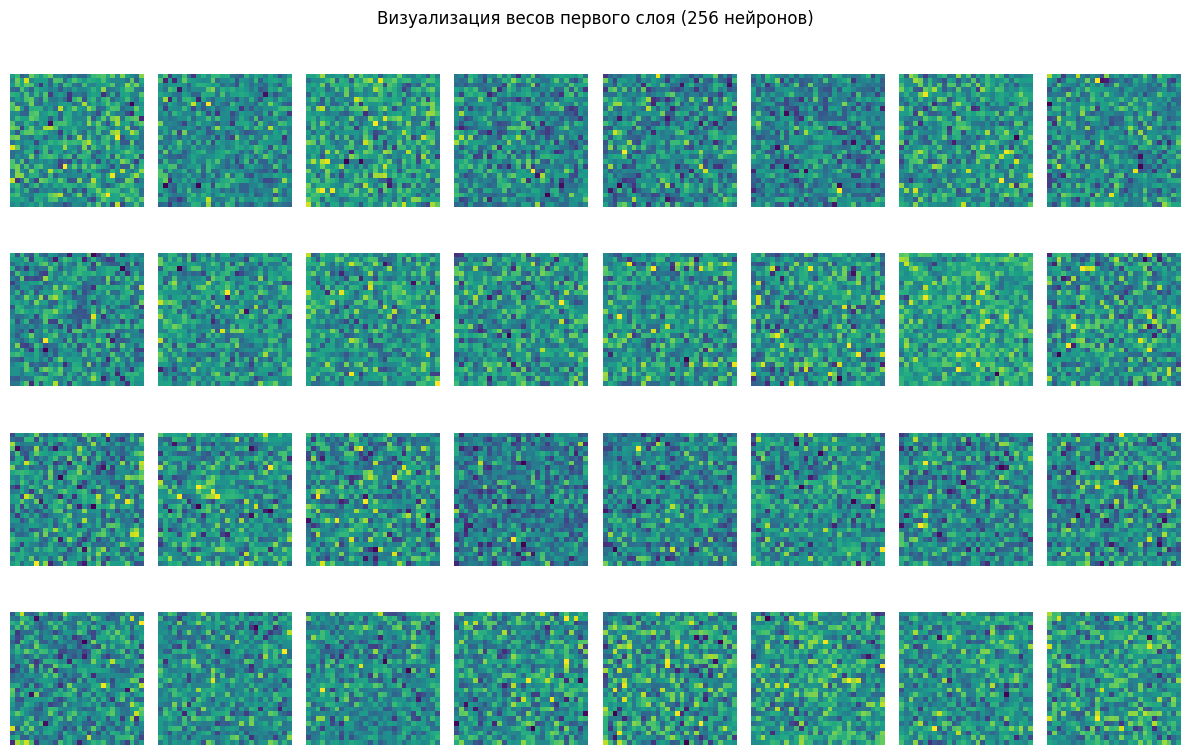

In [20]:
best_model = histories['he']['model']  # из первого эксперимента
weights = best_model.fc1.weight.detach().cpu().numpy()  # (256, 784)

# Отобразим первые 32 нейрона
plt.figure(figsize=(12,8))
for i in range(32):
    plt.subplot(4,8,i+1)
    w = weights[i].reshape(28,28)
    plt.imshow(w, cmap='viridis')
    plt.axis('off')
plt.suptitle('Визуализация весов первого слоя (256 нейронов)')
plt.tight_layout()
plt.show()

## 7. Выводы

В этом практическом занятии мы:
- Загрузили реальный набор данных MNIST и построили простой MLP.
- Сравнили различные инициализации весов и убедились, что Xavier и He дают лучшую сходимость, чем случайная большая инициализация.
- Исследовали влияние скорости обучения и увидели, что слишком маленький шаг замедляет обучение, а слишком большой может привести к нестабильности.
- Визуализировали веса первого слоя, которые показывают, что нейроны учатся распознавать характерные штрихи цифр.

Эти эксперименты демонстрируют важность правильного выбора гиперпараметров при обучении нейросетей.